# Practica CNN

## Ejemplo 1

> Nota: Se tarda mucho si no se corre con GPU
> 

Entrenar una red neuronal convolucional sencilla para clasificar dígitos del conjunto **Fruits-360.** 

**Fruits-360 e**s una base de datos de imágenes de frutas (y algunas verduras) tomadas en diferentes ángulos y fondos controlados.

- 📦 **Total de clases:** 131 clases
- 🖼️ **Tamaño de imagen:** 100×100 píxeles
- 🧮 **Número total de imágenes:** ≈90,000
- 📚 **Fuente oficial:**
    
    👉 https://www.kaggle.com/datasets/moltean/fruits
    

### Descargar base de datos y cargarla

In [1]:
!git clone https://github.com/Horea94/Fruit-Images-Dataset.git

Clonando en 'Fruit-Images-Dataset'...
remote: Enumerating objects: 385861, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 385861 (delta 0), reused 0 (delta 0), pack-reused 385858 (from 1)
Recibiendo objetos: 100% (385861/385861), 2.10 GiB | 68.33 MiB/s, listo.
Resolviendo deltas: 100% (1202/1202), listo.
Actualizando archivos: 100% (90503/90503), listo.


In [1]:
# ============================================================
# CLASIFICACIÓN DE IMÁGENES DE FRUTAS con CNN (PyTorch)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Transformaciones (a tensor + normalización)
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])
# ------------------------------------------------------------
# 2. Cargar el dataset Fruits-360
# ------------------------------------------------------------
data_dir = './Fruit-Images-Dataset/'  # Cambia si está en otro lugar
train_dataset = datasets.ImageFolder(root=data_dir + 'Training', transform=transform)
test_dataset  = datasets.ImageFolder(root=data_dir + 'Test', transform=transform)

## División correcta del dataset

| Conjunto | Propósito | Tamaño típico |
| --- | --- | --- |
| **Entrenamiento (train)** | Para ajustar los pesos de la red | 80% del total |
| **Validación (val)** | Para elegir hiperparámetros y evitar sobreajuste | 10% |
| **Prueba (test)** | Para medir rendimiento final (sin tocar el modelo entrenado) | 10% |

In [4]:
# ------------------------------------------------------------
# 3. Dividir entrenamiento en train y validación
# ------------------------------------------------------------
train_size = int(0.8 * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
# ------------------------------------------------------------
# 4. Crear DataLoaders
# ------------------------------------------------------------
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Visualizar base imágenes

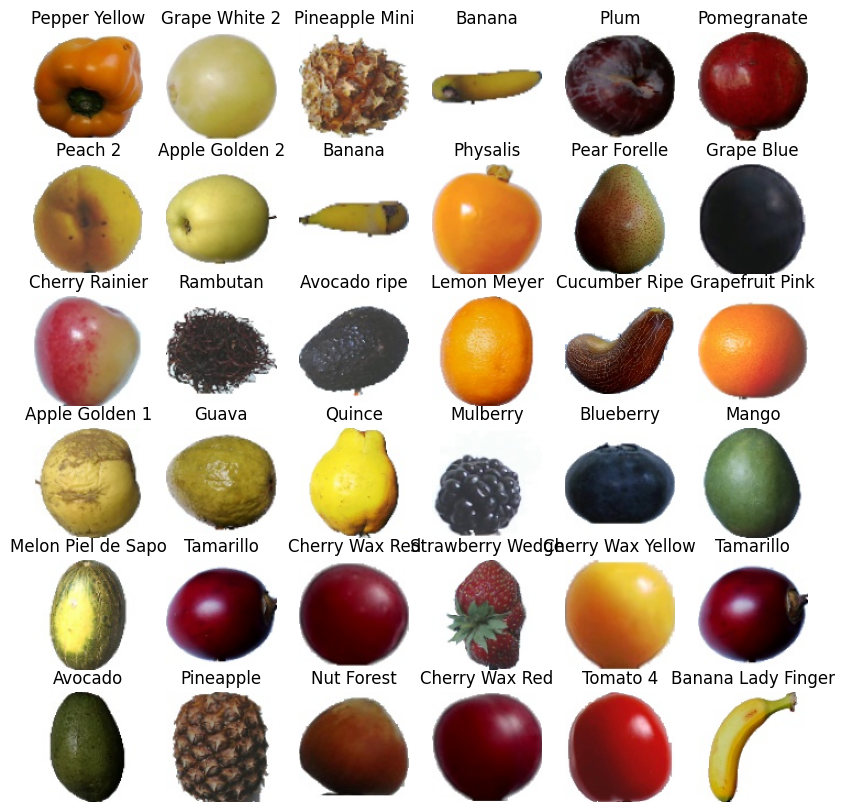

In [5]:
# ------------------------------------------------------------
# 5. Visualizar algunas imágenes (30x30 muestras)
# ------------------------------------------------------------
def show_batch(loader):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(6, 6, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        img = images[i] / 2 + 0.5  # desnormalizar
        npimg = img.numpy().transpose((1, 2, 0))
        ax.imshow(npimg)
        ax.axis('off')
        ax.set_title(train_dataset.dataset.classes[labels[i]])
    plt.show()

show_batch(train_loader)

## Definir modelo CNN

In [6]:
# ------------------------------------------------------------
# 6. Definir una CNN sencilla
# ------------------------------------------------------------
class FruitCNN(nn.Module):
    def __init__(self, num_classes):
        super(FruitCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 25 * 25, 256)
        self.fc2   = nn.Linear(256, num_classes)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 25 * 25)
        x = self.drop(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

num_classes = len(train_dataset.dataset.classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FruitCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Entrenamiento

Época [1/10]  Train Loss: 0.4886  Val Loss: 0.0123  Val Acc: 99.65%
Época [2/10]  Train Loss: 0.0462  Val Loss: 0.0102  Val Acc: 99.65%
Época [3/10]  Train Loss: 0.0360  Val Loss: 0.0048  Val Acc: 99.87%
Época [4/10]  Train Loss: 0.0307  Val Loss: 0.0044  Val Acc: 99.91%
Época [5/10]  Train Loss: 0.0221  Val Loss: 0.0102  Val Acc: 99.69%
Época [6/10]  Train Loss: 0.0181  Val Loss: 0.0048  Val Acc: 99.90%
Época [7/10]  Train Loss: 0.0188  Val Loss: 0.0010  Val Acc: 99.99%
Época [8/10]  Train Loss: 0.0190  Val Loss: 0.0013  Val Acc: 99.99%
Época [9/10]  Train Loss: 0.0131  Val Loss: 0.0003  Val Acc: 99.99%
Época [10/10]  Train Loss: 0.0134  Val Loss: 0.0006  Val Acc: 99.99%


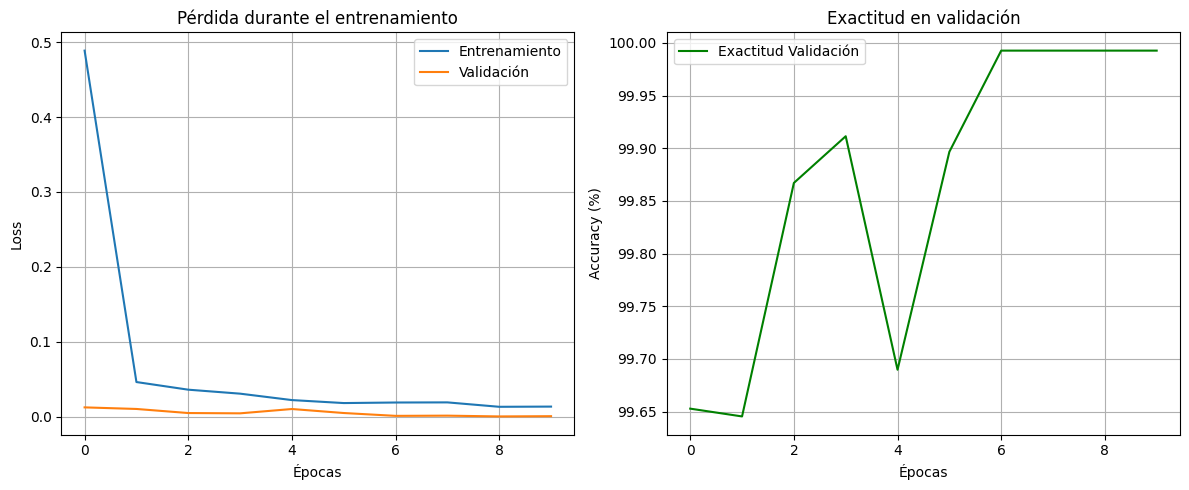

In [8]:
# ------------------------------------------------------------
# 7. Entrenamiento con validación
# ------------------------------------------------------------
num_epochs = 10

train_losses, val_losses = [], []
val_accuracies = []

for epoch in range(num_epochs):
    # ---- Entrenamiento ----
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- Validación ----
    model.eval()
    correct, total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Época [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss/len(val_loader):.4f}  "
          f"Val Acc: {val_acc:.2f}%")

# ------------------------------------------------------------
# 8. Graficar métricas de entrenamiento
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

# --- Pérdida ---
plt.subplot(1,2,1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Exactitud ---
plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Exactitud Validación', color='green')
plt.title('Exactitud en validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Ejemplo  2 con MNIST

100.0%
100.0%
100.0%
100.0%


Época [1/8]  Train Loss: 0.1921  Val Loss: 0.0720  Val Acc: 97.70%
Época [2/8]  Train Loss: 0.0571  Val Loss: 0.0666  Val Acc: 97.88%
Época [3/8]  Train Loss: 0.0399  Val Loss: 0.0478  Val Acc: 98.58%
Época [4/8]  Train Loss: 0.0294  Val Loss: 0.0355  Val Acc: 99.02%
Época [5/8]  Train Loss: 0.0234  Val Loss: 0.0355  Val Acc: 98.86%
Época [6/8]  Train Loss: 0.0169  Val Loss: 0.0399  Val Acc: 98.90%
Época [7/8]  Train Loss: 0.0152  Val Loss: 0.0413  Val Acc: 98.86%
Época [8/8]  Train Loss: 0.0110  Val Loss: 0.0444  Val Acc: 98.83%


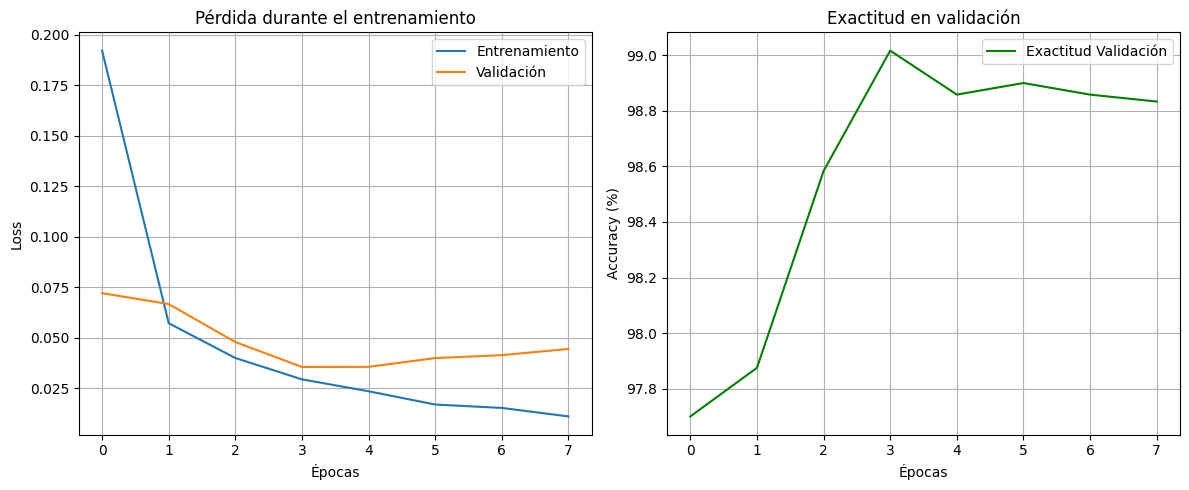


🔹 Exactitud en conjunto de prueba: 98.99%


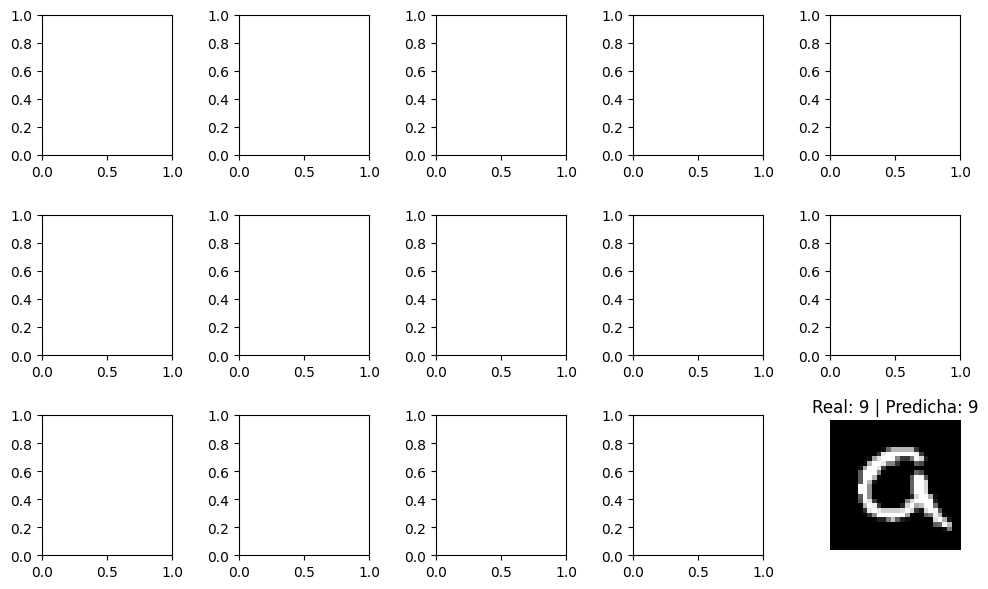

In [1]:
# ============================================================
# CLASIFICACIÓN DE IMÁGENES (MNIST) con CNN + GRÁFICAS + INFERENCIA
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Transformaciones (normalización y conversión a tensor)
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ------------------------------------------------------------
# 2. Cargar el dataset MNIST
# ------------------------------------------------------------
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# ------------------------------------------------------------
# 3. Dividir entrenamiento en train y validación
# ------------------------------------------------------------
train_size = int(0.8 * len(mnist_train))
val_size   = len(mnist_train) - train_size
train_dataset, val_dataset = random_split(mnist_train, [train_size, val_size])

# ------------------------------------------------------------
# 4. Crear DataLoaders
# ------------------------------------------------------------
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

# ------------------------------------------------------------
# 5. Definir una CNN sencilla (tipo LeNet)
# ------------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(32 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ------------------------------------------------------------
# 6. Inicializar modelo, función de pérdida y optimizador
# ------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------------------------------------------------
# 7. Entrenamiento con validación y registro de métricas
# ------------------------------------------------------------
num_epochs = 8
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    # ---- Entrenamiento ----
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- Validación ----
    model.eval()
    correct, total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Época [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss/len(val_loader):.4f}  "
          f"Val Acc: {val_acc:.2f}%")

# ------------------------------------------------------------
# 8. Graficar métricas
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

# --- Pérdida ---
plt.subplot(1,2,1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Exactitud ---
plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Exactitud Validación', color='green')
plt.title('Exactitud en validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Evaluación final (Test)
# ------------------------------------------------------------
model.eval()
correct, total = 0, 0
predictions, images_all, labels_all = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        predictions.extend(predicted.cpu().numpy())
        images_all.extend(images.cpu())
        labels_all.extend(labels.cpu().numpy())

print(f"\n🔹 Exactitud en conjunto de prueba: {100 * correct / total:.2f}%")

# ------------------------------------------------------------
# 10. Mostrar inferencias visuales
# ------------------------------------------------------------
def imshow(img, label_real, label_pred):
    img = img / 2 + 0.5  # desnormalizar
    npimg = img.numpy().squeeze()
    plt.imshow(npimg, cmap='gray')
    plt.title(f"Real: {label_real} | Predicha: {label_pred}")
    plt.axis('off')

# Mostrar algunas imágenes con sus predicciones
fig, axes = plt.subplots(3, 5, figsize=(10,6))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(images_all))
    imshow(images_all[idx], labels_all[idx], predictions[idx])
plt.tight_layout()
plt.show()


# Ejemplo 3 VGG16 don fine tuning

### ¿Qué es *Fine-Tuning*?

**Fine-tuning** (ajuste fino) es una técnica de **aprendizaje por transferencia (*transfer learning*)**, en la cual tomamos una **red neuronal ya entrenada** (por ejemplo, una CNN entrenada en *ImageNet*) y **la adaptamos a una nueva tarea o dataset diferente**, sin tener que entrenarla desde cero.

/home/tvillasenor/dev/2026/UNAM/PracticaCNN/.venv/lib64/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tvillasenor/dev/2026/UNAM/PracticaCNN/.venv/lib64/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/tvillasenor/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


Época [1/5] | Train Loss: 0.1424 | Val Loss: 0.0818 | Val Acc: 98.00%
Época [2/5] | Train Loss: 0.0802 | Val Loss: 0.0595 | Val Acc: 98.70%
Época [3/5] | Train Loss: 0.0709 | Val Loss: 0.0523 | Val Acc: 98.80%
Época [4/5] | Train Loss: 0.0722 | Val Loss: 0.0651 | Val Acc: 98.66%
Época [5/5] | Train Loss: 0.0462 | Val Loss: 0.0632 | Val Acc: 98.91%


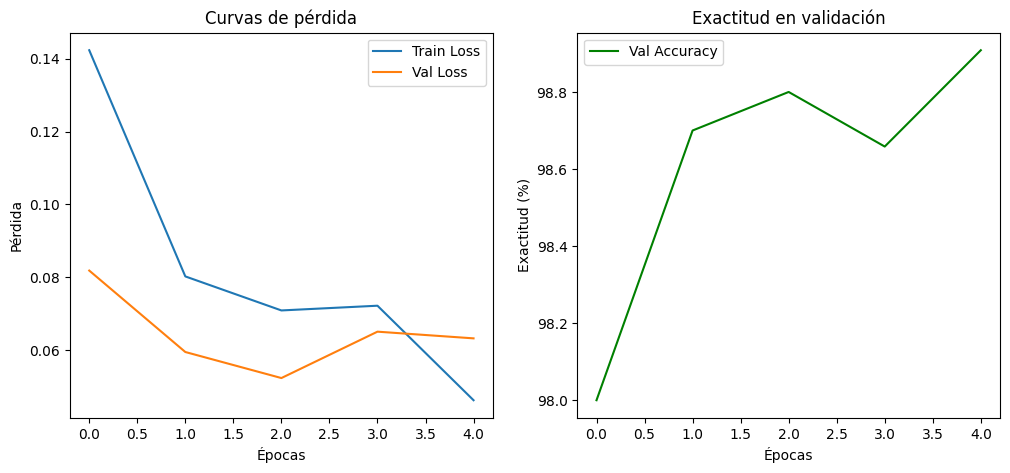


Exactitud en conjunto de prueba: 99.08%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8112855].


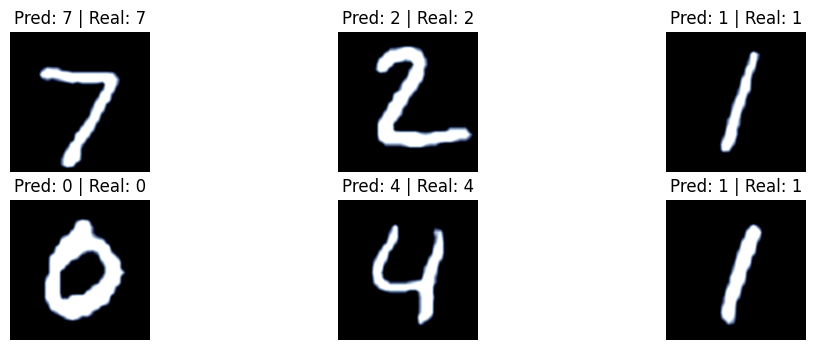

In [1]:
# ============================================================
# CLASIFICACIÓN DE IMÁGENES (MNIST) con VGG16 Preentrenada
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Transformaciones
# ------------------------------------------------------------
# VGG16 espera imágenes de 3 canales (RGB) y tamaño 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # duplicamos el canal
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # valores de ImageNet
                         std=[0.229, 0.224, 0.225])
])

# ------------------------------------------------------------
# 2. Cargar el dataset MNIST
# ------------------------------------------------------------
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# ------------------------------------------------------------
# 3. Dividir en entrenamiento y validación
# ------------------------------------------------------------
train_size = int(0.8 * len(mnist_train))
val_size   = len(mnist_train) - train_size
train_dataset, val_dataset = random_split(mnist_train, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

# ------------------------------------------------------------
# 4. Cargar VGG16 preentrenada y modificar la última capa
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg16 = models.vgg16(pretrained=True)

# Congelar las capas convolucionales (solo entrenaremos las FC)
for param in vgg16.features.parameters():
    param.requires_grad = False

# Cambiar la última capa para 10 clases (MNIST)
vgg16.classifier[6] = nn.Linear(4096, 10)

vgg16 = vgg16.to(device)

# ------------------------------------------------------------
# 5. Función de pérdida y optimizador
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=0.0005)

# ------------------------------------------------------------
# 6. Entrenamiento con validación
# ------------------------------------------------------------
num_epochs = 5
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    # ---- Entrenamiento ----
    vgg16.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- Validación ----
    vgg16.eval()
    correct, total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Época [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.2f}%")

# ------------------------------------------------------------
# 7. Graficar pérdida y precisión
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.title("Curvas de pérdida")

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Val Accuracy", color="green")
plt.xlabel("Épocas")
plt.ylabel("Exactitud (%)")
plt.legend()
plt.title("Exactitud en validación")

plt.show()

# ------------------------------------------------------------
# 8. Evaluación final (Test)
# ------------------------------------------------------------
vgg16.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg16(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nExactitud en conjunto de prueba: {100 * correct / total:.2f}%")

# ------------------------------------------------------------
# 9. Inferencia: Mostrar imágenes y predicciones
# ------------------------------------------------------------
def imshow(img):
    img = img / 2 + 0.5  # desnormalizar un poco
    npimg = img.numpy().transpose((1, 2, 0))
    plt.imshow(npimg)
    plt.axis('off')

# Tomar un batch del test
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = vgg16(images)
_, preds = torch.max(outputs, 1)

# Mostrar primeras 6 imágenes y predicciones
plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    imshow(images[i].cpu())
    plt.title(f"Pred: {preds[i].item()} | Real: {labels[i].item()}")
plt.show()


## **Serie de ejercicios con CNN, AlexNet y ResNet sobre Caltech101**

**Dataset a utilizar: Caltech101**

- **Fuente:** https://data.caltech.edu/records/20086
    
    (También disponible directamente en `torchvision.datasets.Caltech101`)
    
- **Número de clases:** 101 objetos + 1 clase de fondo ("background")
- **Número de imágenes:** ~9 000 imágenes a color
- **Tamaño de imagen:** variable (usualmente 300×200 aprox.)
- **Tamaño típico de entrada:** redimensionar a 224×224
- **División sugerida:**
    - 70 % entrenamiento
    - 15 % validación
    - 15 % prueba

# Ejercicio 1 – Diseña una CNN desde cero

## Arquitectura
```
Entrada: 3x224x224
Conv(32, 3x3, padding=1) → ReLU → MaxPool(2x2)
Conv(64, 3x3, padding=1) → ReLU → MaxPool(2x2)
Conv(128, 3x3, padding=1) → ReLU → Flatten
FC(512) → ReLU → Dropout(0.5)
FC(102)  # 101 clases + 1 fondo
```

## Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [16]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: x.convert('RGB') if x.mode != 'RGB' else x),  # Convertir a RGB si es necesario
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [17]:
# Descargar dataset Caltech101 con transformación
caltech = datasets.Caltech101(
    root='./data/caltech101',
    download=True,
    transform=transform
)

In [18]:
train_size = int(0.7 * len(caltech))
val_size = int(0.15 * len(caltech))
test_size = len(caltech) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(caltech, [train_size, val_size, test_size])

In [19]:
# ------------------------------------------------------------
# 4. Crear DataLoaders
# ------------------------------------------------------------
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

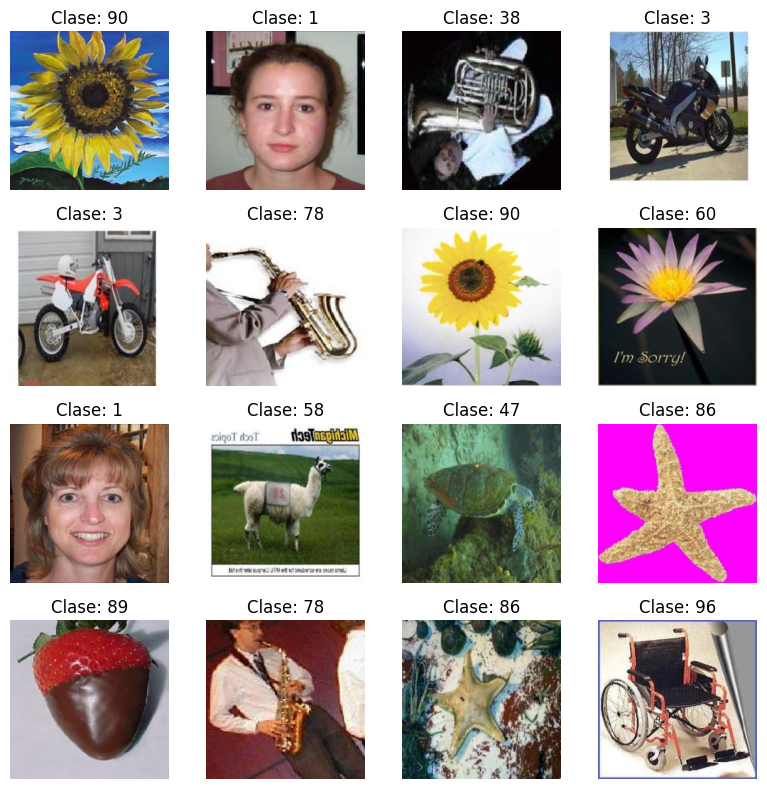

In [20]:
# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Visualizar algunas imágenes
def show_batch(loader):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        img = images[i] / 2 + 0.5  # desnormalizar
        npimg = img.numpy().transpose((1, 2, 0))
        ax.imshow(npimg)
        ax.axis('off')
        ax.set_title(f"Clase: {labels[i].item()}")
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [21]:
# ------------------------------------------------------------
# 6. Definir una CNN según la arquitectura especificada
# ------------------------------------------------------------
class CaltechCNN(nn.Module):
    def __init__(self, num_classes):
        super(CaltechCNN, self).__init__()
        # Capas convolucionales
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        # Capas fully connected
        self.fc1   = nn.Linear(128 * 28 * 28, 512)
        self.fc2   = nn.Linear(512, num_classes)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(0.5)

    def forward(self, x):
        # Conv1: 224x224 → 112x112
        x = self.pool(self.relu(self.conv1(x)))
        # Conv2: 112x112 → 56x56
        x = self.pool(self.relu(self.conv2(x)))
        # Conv3: 56x56 → 28x28
        x = self.pool(self.relu(self.conv3(x)))
        # Flatten
        x = x.view(-1, 128 * 28 * 28)
        # FC1 + ReLU + Dropout
        x = self.drop(self.relu(self.fc1(x)))
        # FC2
        x = self.fc2(x)
        return x

num_classes = 102  # 101 clases + 1 fondo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CaltechCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Época [1/10]  Train Loss: 3.5116  Val Loss: 2.8173  Val Acc: 39.89%
Época [2/10]  Train Loss: 2.5771  Val Loss: 2.2849  Val Acc: 50.19%
Época [3/10]  Train Loss: 1.8963  Val Loss: 1.9326  Val Acc: 56.03%
Época [4/10]  Train Loss: 1.3115  Val Loss: 1.8308  Val Acc: 57.72%
Época [5/10]  Train Loss: 0.8214  Val Loss: 1.8767  Val Acc: 58.34%
Época [6/10]  Train Loss: 0.5259  Val Loss: 2.0150  Val Acc: 58.19%
Época [7/10]  Train Loss: 0.3678  Val Loss: 2.0612  Val Acc: 59.49%
Época [8/10]  Train Loss: 0.2649  Val Loss: 2.2756  Val Acc: 58.95%
Época [9/10]  Train Loss: 0.2144  Val Loss: 2.4051  Val Acc: 59.19%
Época [10/10]  Train Loss: 0.1836  Val Loss: 2.3761  Val Acc: 58.42%


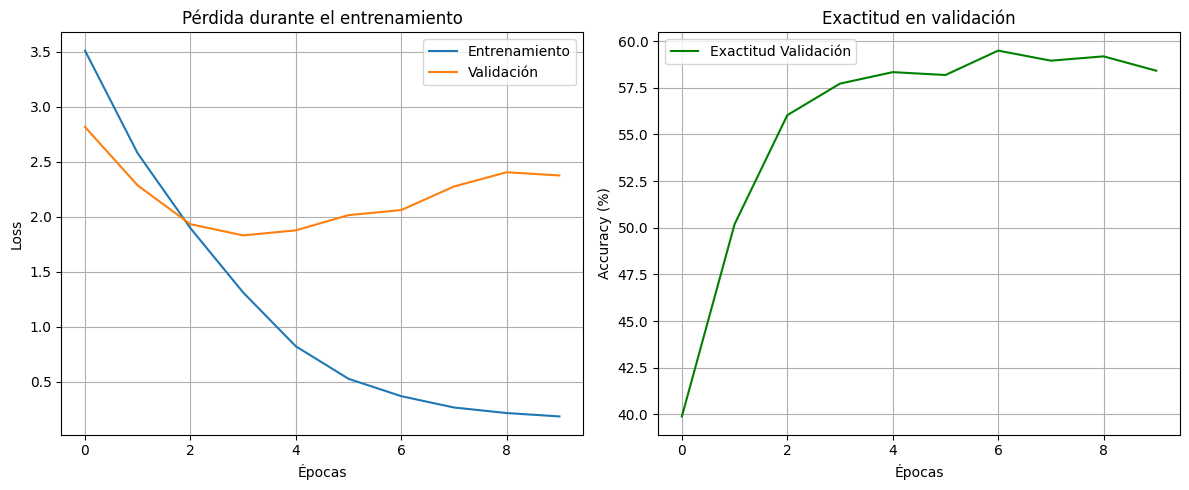

In [22]:
# ------------------------------------------------------------
# 7. Entrenamiento con validación
# ------------------------------------------------------------
num_epochs = 10

train_losses, val_losses = [], []
val_accuracies = []

for epoch in range(num_epochs):
    # ---- Entrenamiento ----
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- Validación ----
    model.eval()
    correct, total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Época [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss/len(val_loader):.4f}  "
          f"Val Acc: {val_acc:.2f}%")

# ------------------------------------------------------------
# 8. Graficar métricas de entrenamiento
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

# --- Pérdida ---
plt.subplot(1,2,1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Exactitud ---
plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Exactitud Validación', color='green')
plt.title('Exactitud en validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()